<a href="https://colab.research.google.com/github/navap3206-debug/hello-world/blob/main/C1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio de regresión logística

|                |   |
:----------------|---|
| **Nombre**     |Carlos Santiago Nava Pulido   |
| **Fecha**      |05/03/2026   |
| **Expediente** |756213   |

In [1]:
from google.colab import files

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [2]:
dt = files.upload()

Saving Default.csv to Default.csv


In [3]:
import pandas as pd

In [4]:
obj = pd.read_csv("Default.csv")

2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [5]:
obj.head(10)

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880
5,No,Yes,919.588531,7491.558572
6,No,No,825.513331,24905.226578
7,No,Yes,808.667504,17600.451340
8,No,No,1161.057854,37468.529290
9,No,No,0.000000,29275.268290


In [6]:
obj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [7]:
obj.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729275
max,2654.322576,73554.233500


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

*Tenemos un DataFrame con 10000 filas y cuatro columnas de datos donde dos se identifican como tipo 'object' y las otras dos como 'float'; las columnas object involucran datos referentes a 'Default' y Student donde se responde 'Yes' o 'No'. En el caso de las columnas numericas poseemos 'balance' e 'income'*

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [8]:
categoricos = ['default', 'student']
obj[categoricos] = obj[categoricos].astype("category")

In [9]:
obj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   default  10000 non-null  category
 1   student  10000 non-null  category
 2   balance  10000 non-null  float64 
 3   income   10000 non-null  float64 
dtypes: category(2), float64(2)
memory usage: 176.2 KB


Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

<Axes: title={'center': 'balance'}, xlabel='[default]'>

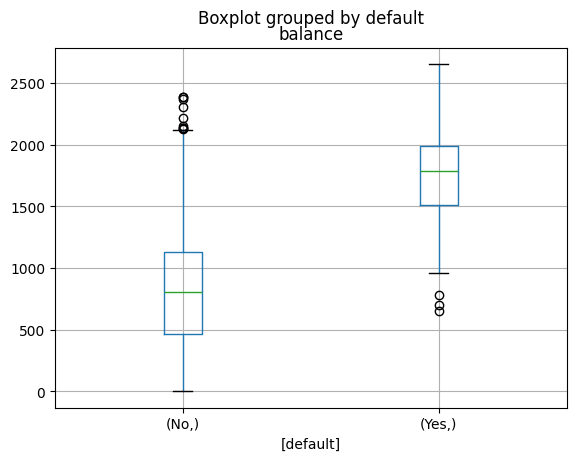

In [10]:
numericos = ['income', 'balance']
obj.boxplot(column=numericos[1],by=['default'])

<Axes: title={'center': 'income'}, xlabel='[default]'>

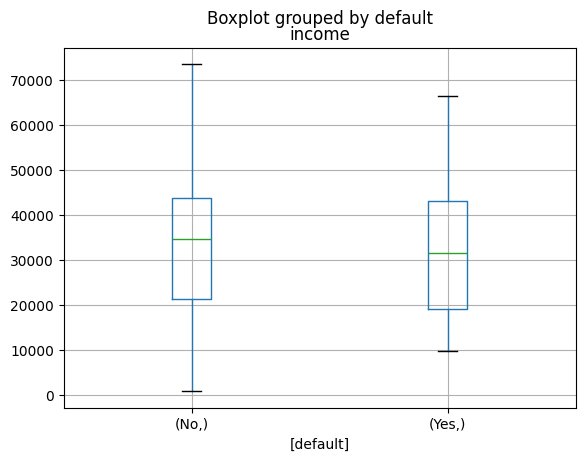

In [11]:
obj.boxplot(column=numericos[0],by=['default'])

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

<Axes: xlabel='balance', ylabel='income'>

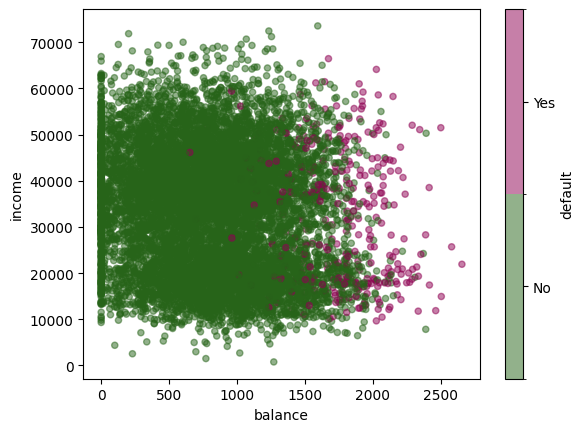

In [12]:
obj.plot.scatter(x='balance', y='income', c="default", colormap="PiYG_r", alpha=0.5)

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías.

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [13]:
y = obj["default"] == "Yes"
y = y.astype(int)
y.head()

,default
0,0
1,0
2,0
3,0
4,0


In [14]:
x = obj['balance'].values.reshape(-1, 1)
x

array([[ 729.52649521],
       [ 817.1804066 ],
       [1073.549164  ],
       ...,
       [ 845.4119892 ],
       [1569.00905338],
       [ 200.92218263]])

Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

<Axes: xlabel='balance', ylabel='y_numeric'>

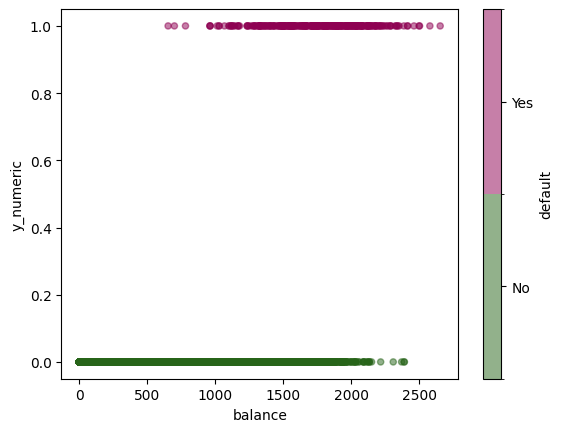

In [15]:
obj['y_numeric'] = y
obj.plot.scatter(x='balance', y='y_numeric', c='default', colormap='PiYG_r', alpha=0.5)


La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [16]:
from sklearn.linear_model import LogisticRegression
import numpy as np

In [17]:
lr = LogisticRegression()
model = lr.fit(x, y)

In [18]:
print(lr.coef_, lr.intercept_)

[[0.00549892]] [-10.65132824]


In [19]:
coef = np.hstack([lr.intercept_.reshape(1, -1), lr.coef_])
coef

array([[-1.06513282e+01,  5.49891555e-03]])

Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [20]:
prediccion = lr.predict_proba(x)[:, 1]
prediccion

array([1.30568146e-03, 2.11259754e-03, 8.59474814e-03, ...,
       2.46651596e-03, 1.16759635e-01, 7.14476480e-05])

In [21]:
prediccion.size

10000

2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [22]:
ans = prediccion * (1-prediccion)
ans

array([1.30397665e-03, 2.10813447e-03, 8.52087844e-03, ...,
       2.46043226e-03, 1.03126823e-01, 7.14425432e-05])

3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [23]:
import numpy as np

In [24]:
V = np.diagflat(ans)

In [25]:
V.shape

(10000, 10000)

4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [26]:
X = np.hstack([np.ones((x.shape[0], 1)), x])#Agregp la columnas 1
X

array([[1.00000000e+00, 7.29526495e+02],
       [1.00000000e+00, 8.17180407e+02],
       [1.00000000e+00, 1.07354916e+03],
       ...,
       [1.00000000e+00, 8.45411989e+02],
       [1.00000000e+00, 1.56900905e+03],
       [1.00000000e+00, 2.00922183e+02]])

In [27]:

cov = np.linalg.inv(X.T @ V @ X)

In [28]:
cov

array([[ 1.30442757e-01, -7.81757265e-05],
       [-7.81757265e-05,  4.85656561e-08]])

5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [29]:
se = np.sqrt(np.diag(cov))

In [30]:
se

array([3.61168600e-01, 2.20376169e-04])

Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [31]:
zj = coef/se

In [32]:
zj

array([[-29.49129089,  24.95240552]])

Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [33]:
from scipy.stats import norm

In [34]:
p_value = 2*(1-norm.cdf(abs(zj)))

In [35]:
p_value.flatten()


array([0., 0.])

¿Es significativa la relación de los factores con la variable de respuesta?

Que el P-value para B0 y B1 sea 0 sgnificaque hay evidencia estadística para decir que si son significativos

Repite el procedimiento con el factor `student`.
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes.
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


In [36]:
#transformamos a 0,1
y_s = obj["student"] == "Yes"
y_s = y_s.astype(int)
y_s


,student
0,0
1,1
2,0
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,0


In [37]:
#NTRENAMOS EL MODELO
lr_2 = LogisticRegression()
model_2 = lr_2.fit(x,y_s)
model_2.coef_, model_2.intercept_

(array([[0.00094086]]), array([-1.70042237]))

In [38]:
#COnseguimos el SE

coef_2 = np.hstack([model_2.intercept_.reshape(-1,1), model_2.coef_.reshape(-1,1)]) #Creo una matriz de coeficientes
p_student = lr_2.predict_proba(x)[:, 1]
ans_2 = (p_student)*(1-p_student)
V_2 = np.diagflat(ans_2)
cov_2 = np.linalg.inv(X.T @ V_2 @ X)
se = np.sqrt(np.diag(cov_2))
se

array([4.87776603e-02, 4.72105573e-05])

In [39]:
#Pvalues
zj2 = coef_2/se
p_value2 = 2*(1-norm.cdf(abs(zj2)))
p_value2.flatten()

array([0., 0.])

LOS VALORES TAMBIÉN SON SIGNIFICATIVOS

## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*.

In [40]:
obj.drop(columns=['y_numeric'], inplace=True)


In [41]:
obj['student'] = y_s
obj['default'] = y
y= obj['default']
x_values = ['balance', 'income', 'student']
x = obj[x_values]

In [42]:
lr_3 = LogisticRegression()
model_3 = lr_3.fit(x,y)
model_3.coef_, model_3.intercept_
coef_3 = np.hstack([model_3.intercept_.reshape(-1,1), model_3.coef_])

In [43]:
#standar error
X = np.hstack([np.ones((x.shape[0], 1)), x])#Agregp la columnas 1
p_coef = lr_3.predict_proba(x)[:, 1]
ans_3 = (p_coef)*(1-p_coef)
V_3 = np.diagflat(ans_3)
cov_3 = np.linalg.inv(X.T @ V_3 @ X)
se = np.sqrt(np.diag(cov_3))
se


array([4.93158470e-01, 2.31675571e-04, 8.20844359e-06, 2.36393913e-01])

In [44]:
#P-values
Zj_3 = coef_3/se
p_value_3 = 2*(1-norm.cdf(abs(Zj_3)))
p_value_3.flatten()

array([0.        , 0.        , 0.62935921, 0.00956079])

In [45]:
import pandas as pd

# Extracting values from existing variables
elementos = ['Intercepto', 'balance', 'income', 'student']
coefficients = coef_3.flatten()
standard_errors = se
z_statistics = Zj_3.flatten()
p_values = p_value_3.flatten()

# Creating the DataFrame
results_df = pd.DataFrame({
    'COLUMNA': elementos,
    'COEFICIENTE': coefficients,
    'STANDARD ERROR': standard_errors,
    'Z': z_statistics,
    'P-value': p_values
})

print(results_df)

      COLUMNA  COEFICIENTE  STANDARD ERROR          Z   P-value
0  Intercepto   -10.901808        0.493158 -22.106095  0.000000
1     balance     0.005731        0.000232  24.735500  0.000000
2      income     0.000004        0.000008   0.482629  0.629359
3     student    -0.612573        0.236394  -2.591322  0.009561


Parece ser que income no tiene significancia al predecir la variable default

¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo. :

En el ambito bursatil el hecho de que generes entradas o compras a mercado donde un modelo te da una señal Falso Positivo es mucho peor que simplemente no arriesgar capital y perder un costo de oportunidad. Otro ejemplo es dentro dd la justicia penal donde un falso positivo representa dañar la reputacion de alguien.

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

Falso Negativo en el diagnostico de enfermedades es mucho peor el falso negativo debido a que no se le daría seguimiento a un problema grave; también esto aplica a detección de fenomenos naturales donde el hecho de no identificarlo podría afectar irrevocablemente miles de familias, mietras que un falso positivo no pasa de un simulacro.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3